In [22]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, SystemMessage
from pydantic import BaseModel, Field
from typing import TypedDict, Literal, Annotated
import operator # Reducers


In [23]:
load_dotenv()

# Create models
generator_llm = ChatOpenAI(model='gpt-4o-mini')
evaluator_llm = ChatOpenAI(model='gpt-4o-mini')
optimizer_llm = ChatOpenAI(model='gpt-4o-mini')

In [24]:
# Create output schema for evaluate llm
class EvaluateSchema(BaseModel):
    approval: Literal['approved', 'needs_improvement'] = Field(..., description='Final evaluation result')
    feedback: str = Field(..., description='Feedback for the tweet...')

evaluator_llm = evaluator_llm.with_structured_output(EvaluateSchema)

In [25]:
# State for graph
class TweetState(TypedDict):
    topic: str
    tweet: str
    approval: Literal['approved', 'needs_improvement']
    feedback: str
    iteration: int
    max_iteration: int

    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]


In [26]:
def generate_tweet(state: TweetState):
    prompt = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
            Write a short, original, and hilarious response on the topic: "{state['topic']}".

            Rules:
            - Do NOT use question-answer format.
            - Max 280 characters.
            - Use observational humor, irony, sarcasm, or cultural references.
            - Think in meme logic, punchlines, or relatable takes.
            - Use simple, day to day english
            """)
            ]
    response = generator_llm.invoke(prompt).content
    return {'tweet': response, 'tweet_history': [response]}

In [34]:
def evaluate_tweet(state: TweetState):
    prompt = [
        SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
        HumanMessage(content=f"""
            Evaluate the following tweet:

            Tweet: "{state['tweet']}"

            Use the criteria below to evaluate the tweet:

            1. Originality – Is this fresh, or have you seen it a hundred times before?  
            2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
            3. Punchiness – Is it short, sharp, and scroll-stopping?  
            4. Virality Potential – Would people retweet or share it?  
            5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

            Auto-reject if:
            - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
            - It exceeds 280 characters
            - It reads like a traditional setup-punchline joke
            - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

            ### Respond ONLY in structured format:
            - evaluation: "approved" or "needs_improvement"  
            - feedback: One paragraph explaining the strengths and weaknesses 
            """)
        ]
    evaluation = evaluator_llm.invoke(prompt)
    return {'approval': evaluation.approval, 'feedback':evaluation.feedback ,'feedback_history': [evaluation.feedback]}

In [35]:
def optimize_tweet(state: TweetState):
    prompt = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
            Improve the tweet based on this feedback:
            "{state['feedback']}"

            Topic: "{state['topic']}"
            Original Tweet:
            {state['tweet']}

            Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
            """)
        ]

    response = optimizer_llm.invoke(prompt).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [36]:
def check_approval(state: TweetState):
    if state['approval'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

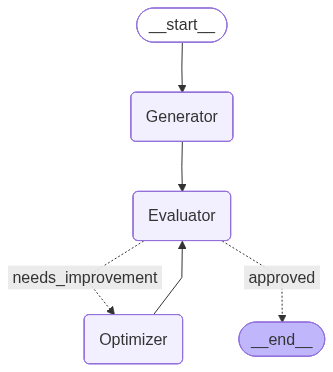

In [37]:
graph = StateGraph(TweetState)

graph.add_node('Generator', generate_tweet)
graph.add_node('Evaluator', evaluate_tweet)
graph.add_node('Optimizer', optimize_tweet)


graph.add_edge(START, 'Generator')
graph.add_edge('Generator', 'Evaluator')
graph.add_conditional_edges('Evaluator', check_approval, {'approved': END, 'needs_improvement': 'Optimizer'})
graph.add_edge('Optimizer', 'Evaluator')

workflow = graph.compile()
workflow

In [39]:
initial_state = {
    'topic': 'AI',
    'iteration': 1,
    'max_iteration': 10
}

final_state = workflow.invoke(initial_state)

In [40]:
final_state

{'topic': 'AI',
 'tweet': 'AI can do math faster than me and remembers where I left my keys... but I’m one crisis away from asking it for relationship advice and lasagna recipes. Next up: AI life hacks for hitting snooze and avoiding adulting like a pro! 🍕🤖😴',
 'approval': 'approved',
 'feedback': 'This tweet showcases a strong blend of originality, humor, and a good punchy format that captures attention without relying on conventional setups or punchlines. The comparison of AI capabilities to personal scenarios—like relationship advice and culinary needs—adds a unique twist that many can relate to, enhancing its humor and making it more memorable. The addition of emojis gives it a playful touch, which complements the topic well. Its relatable theme also boosts virality potential, as many will likely share the sentiments expressed.',
 'iteration': 2,
 'max_iteration': 10,
 'tweet_history': ["AI: the only thing that can do math faster than me while simultaneously forgetting where I left